In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
mainPath = os.path.abspath(os.path.join(os.getcwd(), '..'))
if mainPath not in sys.path:
    sys.path.insert(0, mainPath)

# ETH_package
### Parameter definition

In [2]:
from building_physics import Zone
import supply_system
import emission_system
from radiation import Location
from radiation import Window
from hvac_operation import update_ventilation
from RC_BuildingSimulator.rc_simulator._BR_ import calc_ach
ElectricityOut = []
HeatingDemand  = []
HeatingEnergy  = []
CoolingDemand  = []
CoolingEnergy  = []
IndoorAir      = []
OutsideTemp    = []
SolarGains     = []
COP            = []

ModuleNotFoundError: No module named 'building_physics'

In [ ]:
# WEATHER
epw_path      = "../../../_data/_epw/ED-TMYx.2023.epw"
EDI           = Location(epwfile_path=epw_path)
year          = 2023
latitude_deg  = 55.95
longitude_deg = -3.37

# GEOMETRY
GEOMETRY = {
    "WINDOW_AREA":  1501.3,
    "WALL_AREA"  :  5168.5,
    "FLOOR_AREA" :  9474.7,
    "VOLUME"     : 37738.8,
    "_alpha"     :     3, # coefficient for 'area of surfaces facing the room'
    "_beta"      :     0.3, # coefficient for 'south windows'
}

# HEATING
t_m_prev = 20

t_set_heating = 21.0          # weekday occupied setpoint
t_weekend_heating = 18.0      # weekend occupied setpoint
t_setback_heating = 12.0      # unoccupied setback
t_set_cooling = 28.0

year = 2023

heating_index = pd.date_range(
    start=f"{year}-01-01 00:00",
    end=f"{year}-12-31 23:00",
    freq="h"
)

weekday_profile = [t_setback_heating] * 8 + [t_set_heating] * 10 + [t_setback_heating] * 6
weekend_profile = [t_setback_heating] * 8 + [t_weekend_heating] * 10 + [t_setback_heating] * 6

heating_schedule = []

for ts in heating_index:
    if ts.weekday() >= 5:   # Saturday=5, Sunday=6
        heating_schedule.extend(weekend_profile)
    else:
        heating_schedule.extend(weekday_profile)


# MV
hr_val           = 0.75
ach_vent, ach_infl    =  calc_ach(
    n_people          = 865,
    fresh_air_lps     = 12.0,
    atrium_ach        = 2.0,
    atrium_volume     = 5739.53,
    infl_rate_m3ph_m2 = 4.0,
    geometry          = GEOMETRY
)
daily_mech       = [ach_vent]*24 
mech_ach         = daily_mech * 365
hour = 0

# IHG
schedule_path    = os.path.join(mainPath, "auxiliary", "schedules_el_OFFICE.csv")
occupancyProfile = pd.read_csv(schedule_path)
gain_per_person  = 100
max_occupancy    = 765
appliance_gains  = 11.77


hr_eff           = []
for m_days, eff_winter in [
    (31,hr_val),(28,hr_val),(31,hr_val),
    (30,hr_val),(31,0.0),(30,0.0),
    (31,0.0),(31,0.0),(30,0.0),
    (31,hr_val),(30,hr_val),(31,hr_val)
]:
    for _ in range(m_days * 24):
        if mech_ach[hour] > 0:
            hr_eff.append(eff_winter)
        else:
            hr_eff.append(0.0)
        hour += 1
# NO DIFFERENCE IF PLACING [0]*6 + [ach_vent]*8 + [0]*10 + [ach_vent]*6

In [ ]:
Office  = Zone(
    window_area                        = GEOMETRY["WINDOW_AREA"],
    walls_area                         = GEOMETRY["WALL_AREA"],
    floor_area                         = GEOMETRY["FLOOR_AREA"],
    room_vol                           = GEOMETRY["VOLUME"],
    total_internal_area                = GEOMETRY["FLOOR_AREA"]*GEOMETRY["_alpha"],
    thermal_capacitance_per_floor_area = 165000,
    u_walls                            = 0.19,
    u_windows                          = 1.41,
    ach_vent                           = ach_vent,
    ach_infl                           = ach_infl,
    lighting_load                      = 4.25,
    t_set_heating                      = 21.0,
    t_set_cooling                      = 28.0,
    ventilation_efficiency             = 0.5,
    max_cooling_energy_per_floor_area  = -np.inf,
    max_heating_energy_per_floor_area  = np.inf,
    heating_supply_system              = supply_system.DirectHeater,
    cooling_supply_system              = supply_system.DirectCooler,
    heating_emission_system            = emission_system.AirConditioning,
    cooling_emission_system            = emission_system.AirConditioning,
)

SouthWindow  = Window(
    azimuth_tilt                      = 0,
    alititude_tilt                    = 90,
    glass_solar_transmittance         = 0.7,
    glass_light_transmittance         = 0.8,
    area                              = GEOMETRY["WINDOW_AREA"] * GEOMETRY["_beta"],
)

### Simulation

Ventilation is not calculated as an airflow network. It is simplified into a single heat-loss conductance between indoor air and supply/outdoor air

In [ ]:
for hour in range(8760):
    # update_ventilation(
    #     Office,
    #     ach_vent=mech_ach[hour],
    #     vent_eff=hr_eff[hour],
    #     ach_infl=ach_infl,
    # )
    Office.t_set_heating = heating_schedule[hour]

    occupancy = occupancyProfile.loc[hour, "People"] * max_occupancy

    internal_gains = occupancy * gain_per_person + appliance_gains * Office.floor_area

    t_out = EDI.weather_data["drybulb_C"][hour]
    
    altitude, azimuth = EDI.calc_sun_position(
        latitude_deg=latitude_deg,longitude_deg=longitude_deg,
        year=year,
        hoy=hour
    )
    SouthWindow.calc_solar_gains(
        sun_altitude=altitude,sun_azimuth=azimuth,
        normal_direct_radiation=EDI.weather_data["dirnorrad_Whm2"][hour],
        horizontal_diffuse_radiation=EDI.weather_data["difhorrad_Whm2"][hour]
    )
    SouthWindow.calc_illuminance(
        sun_altitude=altitude,sun_azimuth=azimuth,
        normal_direct_illuminance=EDI.weather_data["dirnorillum_lux"][hour],
        horizontal_diffuse_illuminance=EDI.weather_data["difhorillum_lux"][hour]
    )
    Office.solve_energy(
        internal_gains=internal_gains,solar_gains=SouthWindow.solar_gains,t_out=t_out,t_m_prev=t_m_prev
    )
    Office.solve_lighting(
        illuminance=SouthWindow.transmitted_illuminance,occupancy=occupancy
    )
    t_m_prev = Office.t_m_next 
    HeatingDemand_kWh_m2 = (Office.heating_demand / 1000.0) /  GEOMETRY["FLOOR_AREA"]
    HeatingEnergy_kWh_m2 = (Office.heating_energy / 1000.0) /  GEOMETRY["FLOOR_AREA"]
    CoolingDemand_kWh_m2 = (Office.cooling_demand / 1000.0) /  GEOMETRY["FLOOR_AREA"]
    CoolingEnergy_kWh_m2 = (Office.cooling_energy / 1000.0) /  GEOMETRY["FLOOR_AREA"]
    ElectricityOut_kWh_m2 = (Office.electricity_out / 1000.0) /  GEOMETRY["FLOOR_AREA"]
    HeatingDemand.append(HeatingDemand_kWh_m2)
    HeatingEnergy.append(HeatingEnergy_kWh_m2)
    CoolingDemand.append(CoolingDemand_kWh_m2)
    CoolingEnergy.append(CoolingEnergy_kWh_m2)
    ElectricityOut.append(ElectricityOut_kWh_m2)
    IndoorAir.append(Office.t_air)
    OutsideTemp.append(t_out)
    SolarGains.append(SouthWindow.solar_gains)
    COP.append(Office.cop)

# Output

In [ ]:
annualResults = pd.DataFrame({
    "HeatingDemand" : HeatingDemand,
    "HeatingEnergy" : HeatingEnergy,
    "CoolingDemand" : CoolingDemand,
    "CoolingEnergy" : CoolingEnergy,
    "IndoorAir"     : IndoorAir,
    "OutsideTemp"   : OutsideTemp,
    "SolarGains"    : SolarGains,
    "COP"           : COP
})
annual_EUI = annualResults[["HeatingEnergy", "CoolingEnergy"]].sum()
annualResults.index = pd.date_range("2023-01-01", periods=8760, freq="h")
print(annual_EUI)
monthly_EUI = (
    annualResults[["HeatingEnergy", "CoolingEnergy"]]
    .resample("ME")
    .sum()
)
monthly_EUI

HeatingEnergy    41.295021
CoolingEnergy     0.078061
dtype: float64


,HeatingEnergy,CoolingEnergy
2023-01-31,6.695127,0.000000
2023-02-28,7.013991,0.000000
2023-03-31,7.681981,0.000000
2023-04-30,4.622423,0.000000
2023-05-31,1.383102,0.000000
2023-06-30,0.000000,0.000000
2023-07-31,0.013446,0.000000
2023-08-31,0.005278,0.000000
2023-09-30,0.165081,0.078061
2023-10-31,3.091444,0.000000


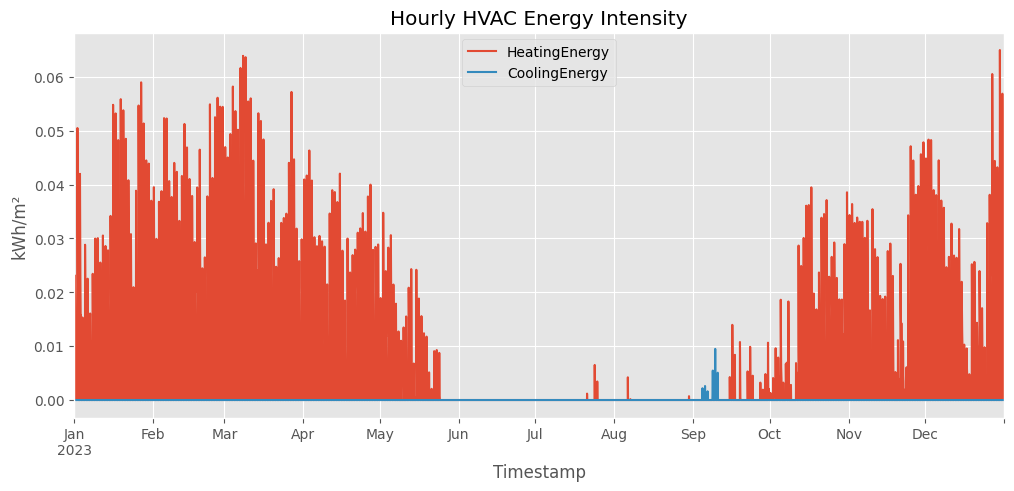

In [ ]:
plt.style.use("ggplot")
ax = annualResults[["HeatingEnergy", "CoolingEnergy"]].plot(figsize=(12,5))
ax.minorticks_off()
plt.ylabel("kWh/m²")
plt.xlabel("Timestamp")
plt.title("Hourly HVAC Energy Intensity")
plt.show()

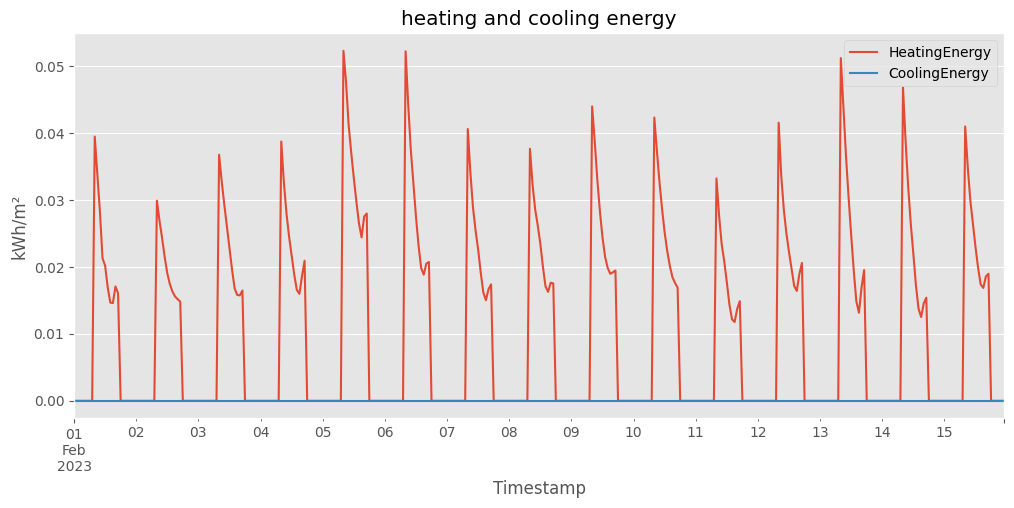

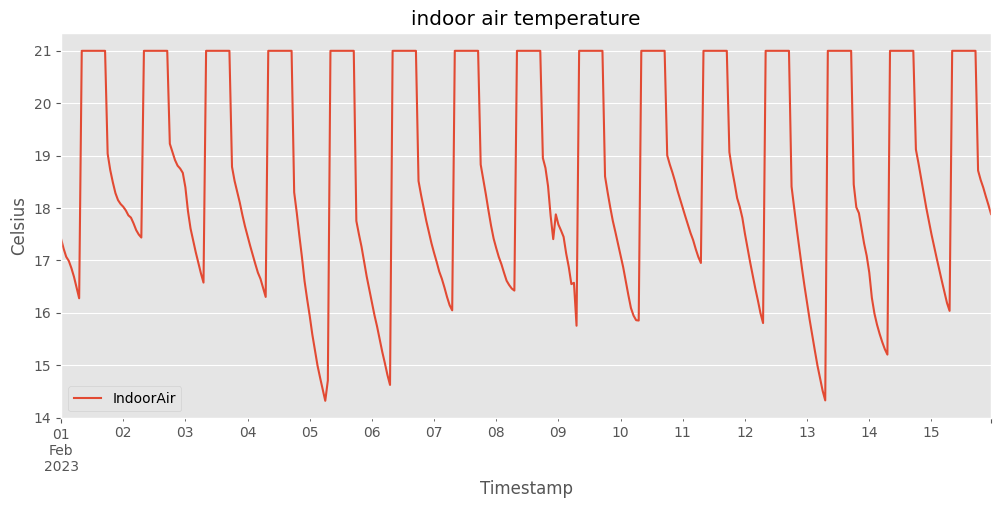

In [ ]:
plt.style.use("ggplot")

march = annualResults.loc["2023-02-01":"2023-02-15 23:00"]

ax = march[["HeatingEnergy", "CoolingEnergy"]].plot(figsize=(12, 5))
plt.ylabel("kWh/m²")
plt.xlabel("Timestamp")
plt.title("heating and cooling energy")
plt.show()

ax = march[["IndoorAir"]].plot(figsize=(12, 5))
plt.ylabel("Celsius")
plt.xlabel("Timestamp")
plt.title("indoor air temperature")
plt.show()